<a href="https://colab.research.google.com/github/7amokarim/breast-cancer-detection-system/blob/main/cnn_2_classifcation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"

print(os.listdir(dataset_path))

['malignant', 'normal', 'benign']


In [ ]:
import cv2
import numpy as np
import os

IMG_SIZE = 224

X = []
y = []

dataset_path = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"

for category in ["benign", "malignant"]:   # ❗ بدون normal
    path = os.path.join(dataset_path, category)

    for file in os.listdir(path):
        if file.endswith(".png"):

            img_path = os.path.join(path, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)

            if category == "benign":
                y.append(0)
            else:
                y.append(1)

X = np.array(X) / 255.0
y = np.array(y)

print(X.shape, y.shape)

(1312, 224, 224, 3) (1312,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_type = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_type.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history = model_type.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7016 - loss: 0.5676 - val_accuracy: 0.7072 - val_loss: 0.6579
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7588 - loss: 0.5037 - val_accuracy: 0.7452 - val_loss: 0.5560
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.8303 - loss: 0.3669 - val_accuracy: 0.7757 - val_loss: 0.6086
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8885 - loss: 0.2860 - val_accuracy: 0.8099 - val_loss: 0.5975
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9199 - loss: 0.2038 - val_accuracy: 0.8251 - val_loss: 0.7792


In [ ]:
loss, acc = model_type.evaluate(X_test, y_test)
print("Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 655ms/step - accuracy: 0.7452 - loss: 0.5560
Accuracy: 0.7452471256256104


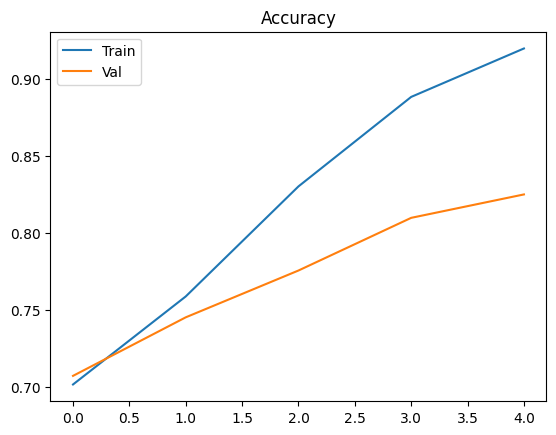

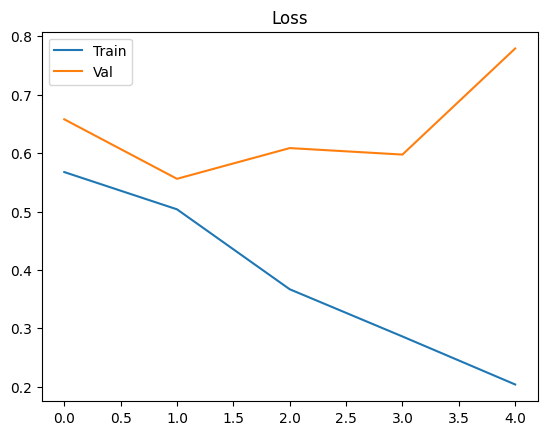

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 507ms/step


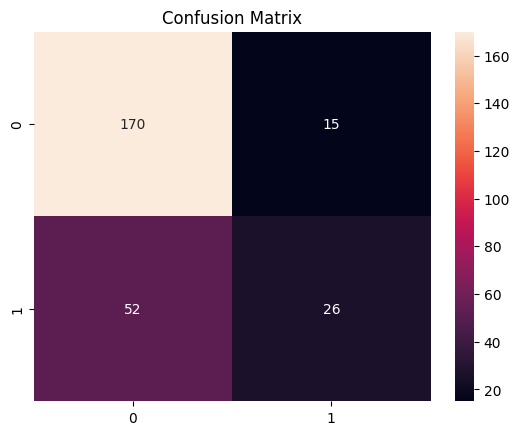

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model_type.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: Benign
True: Malignant


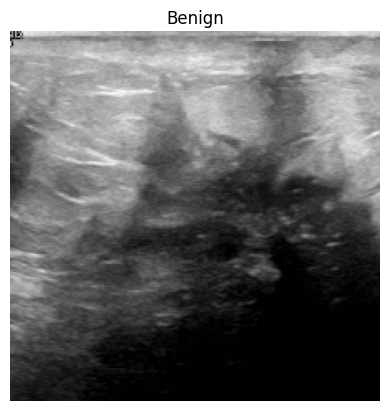

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prediction: Benign
True: Benign


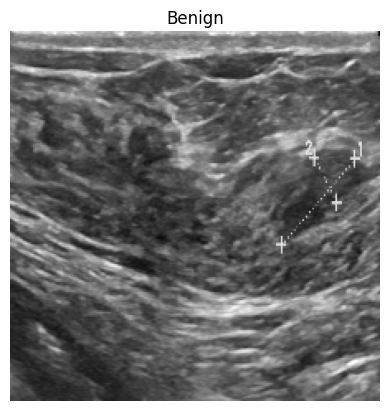

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Prediction: Benign
True: Benign


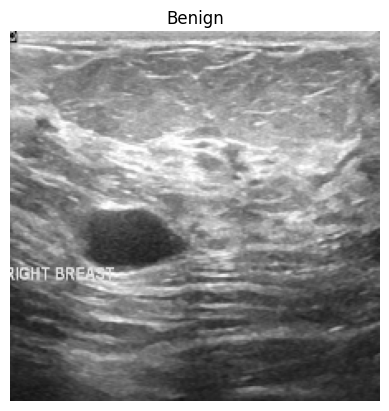

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: Malignant
True: Benign


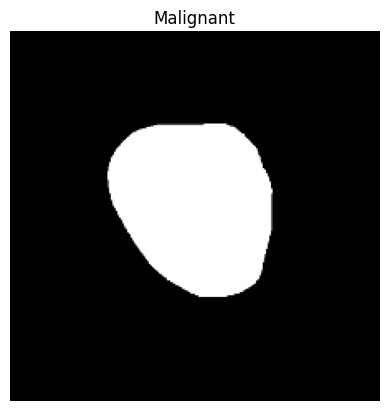

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: Benign
True: Benign


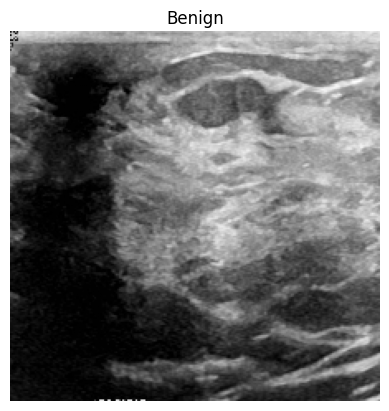

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: Benign
True: Benign


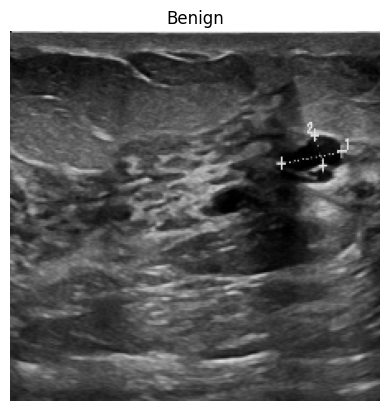

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: Benign
True: Benign


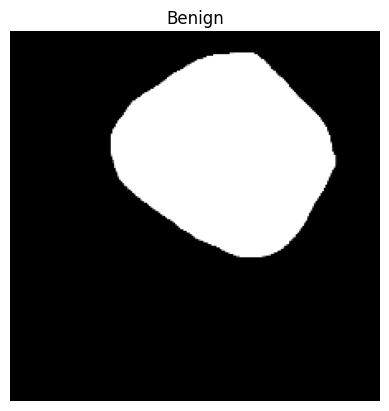

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: Benign
True: Benign


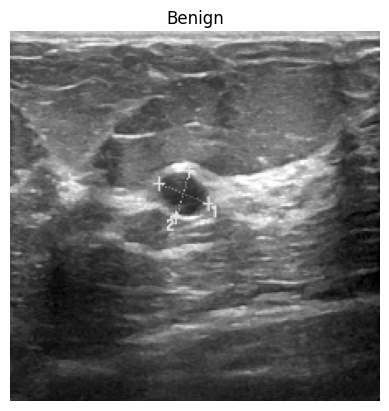

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: Benign
True: Malignant


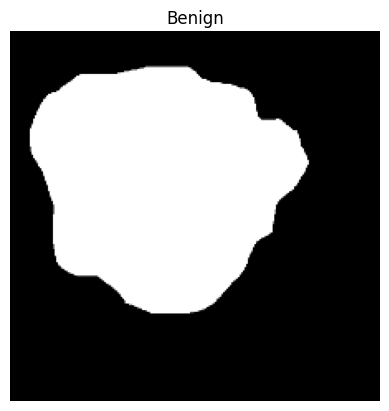

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: Benign
True: Benign


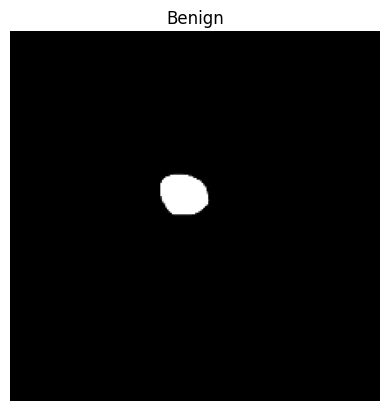

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: Malignant
True: Malignant


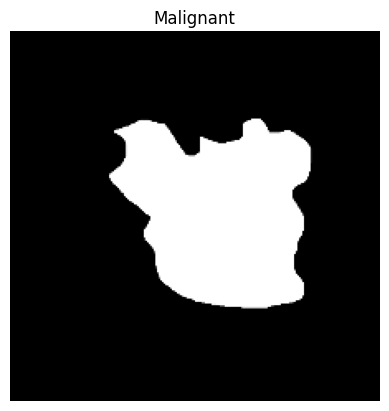

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: Benign
True: Benign


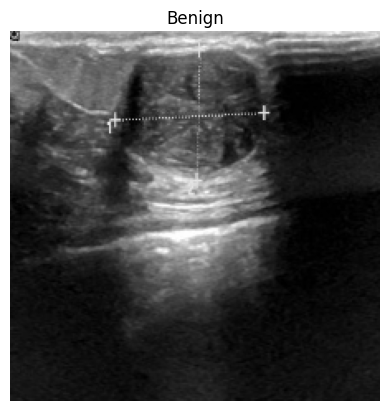

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: Benign
True: Benign


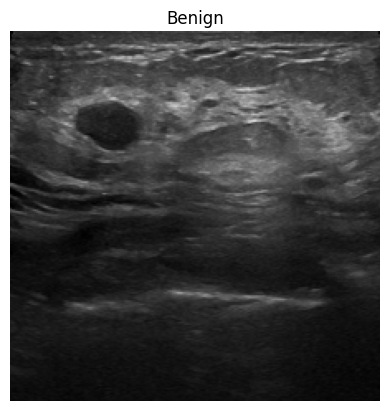

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Prediction: Benign
True: Malignant


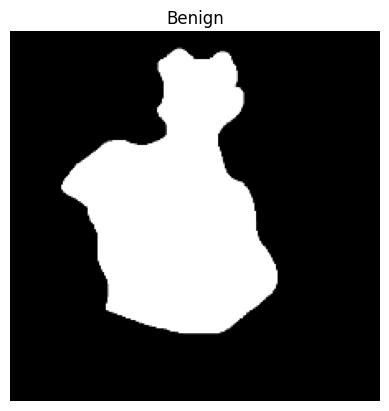

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction: Benign
True: Malignant


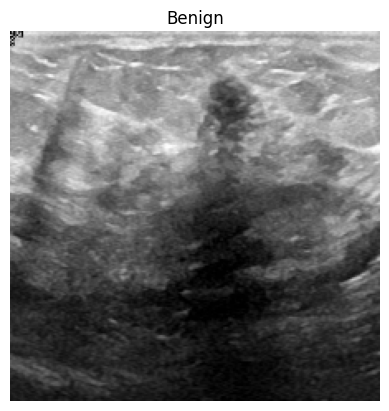

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: Benign
True: Benign


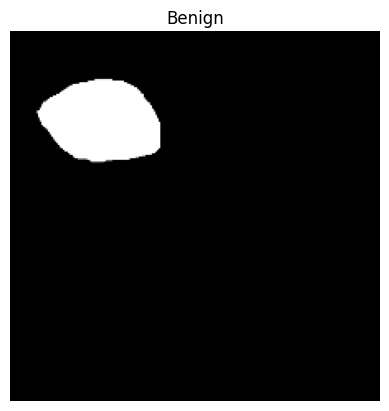

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Benign
True: Benign


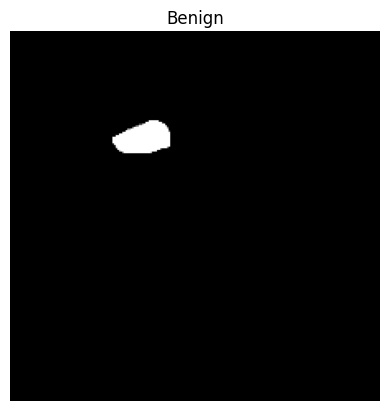

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: Benign
True: Benign


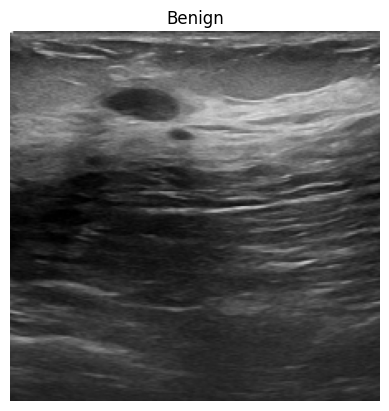

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prediction: Benign
True: Benign


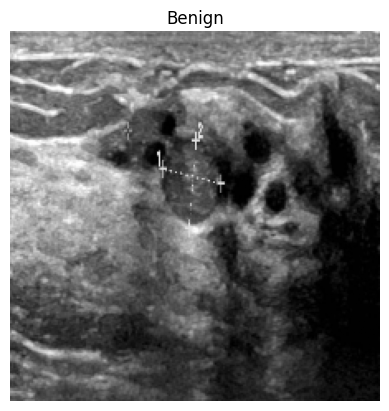

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: Benign
True: Benign


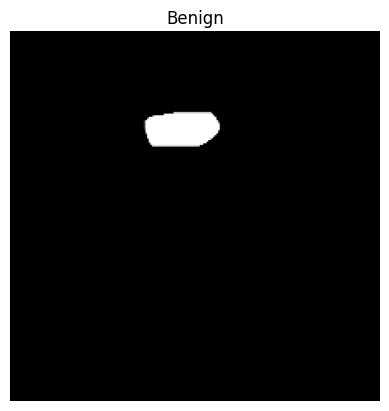

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: Benign
True: Malignant


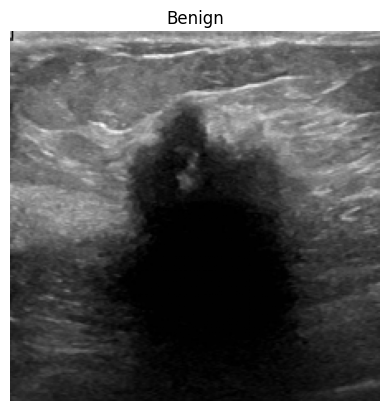

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction: Benign
True: Benign


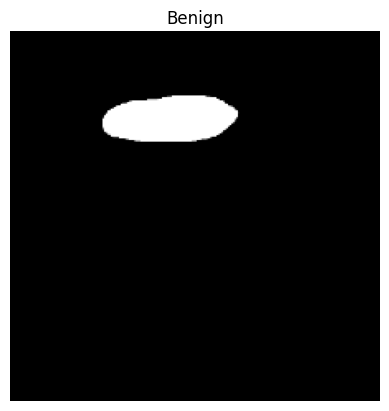

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Prediction: Malignant
True: Benign


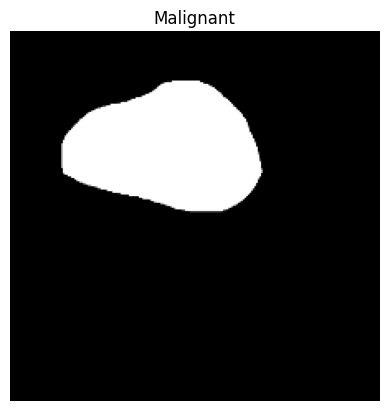

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: Benign
True: Benign


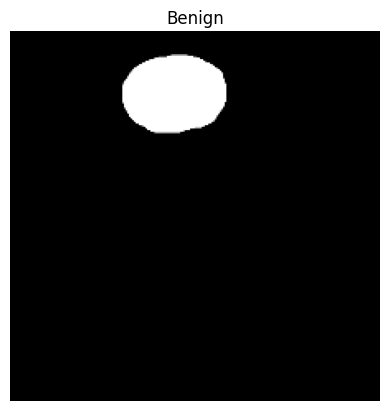

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: Benign
True: Benign


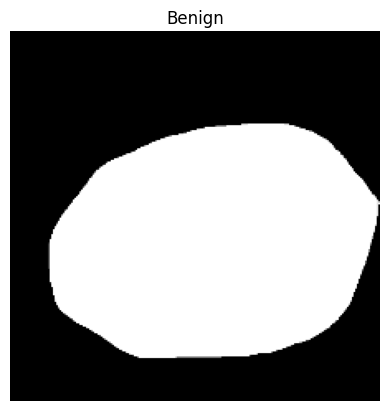

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Benign
True: Benign


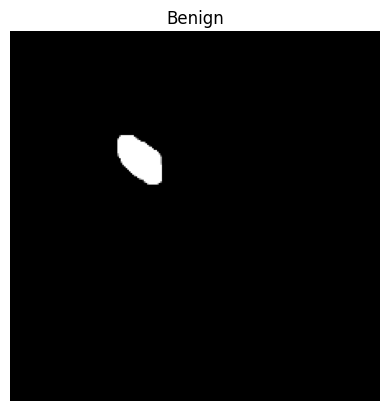

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction: Malignant
True: Malignant


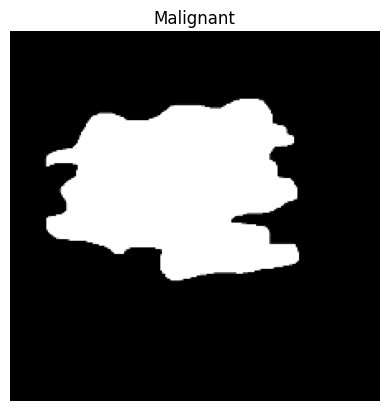

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: Benign
True: Benign


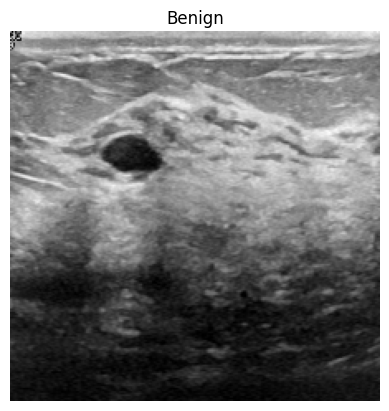

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Prediction: Benign
True: Malignant


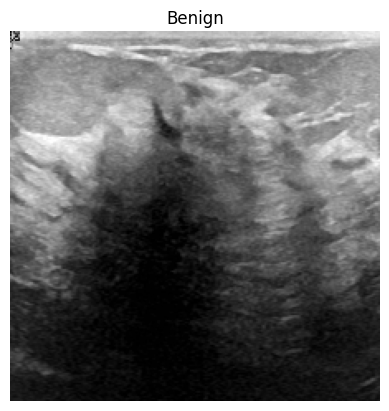

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: Benign
True: Benign


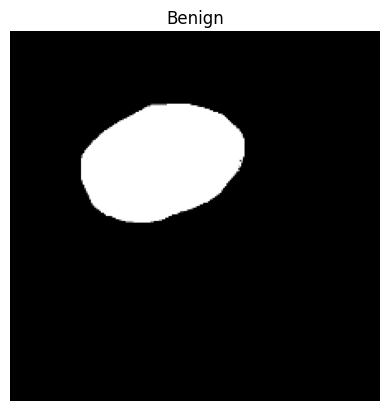

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: Benign
True: Malignant


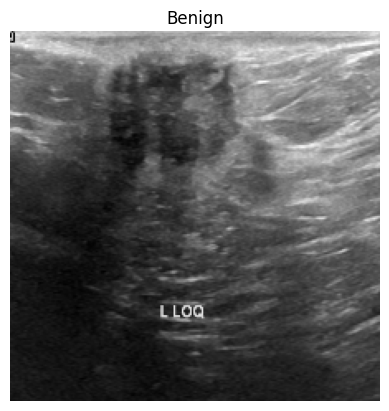

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediction: Benign
True: Benign


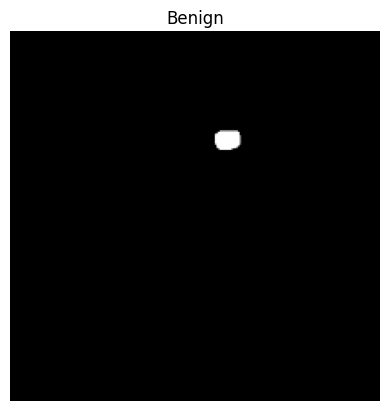

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: Benign
True: Benign


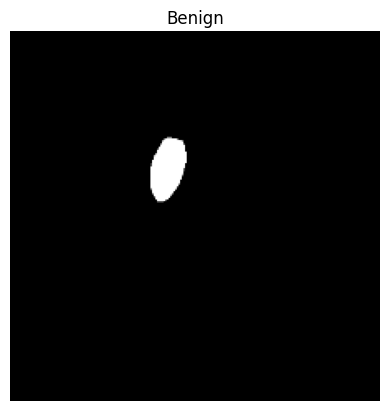

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: Benign
True: Malignant


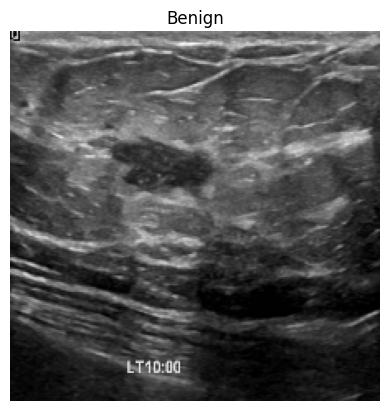

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: Benign
True: Benign


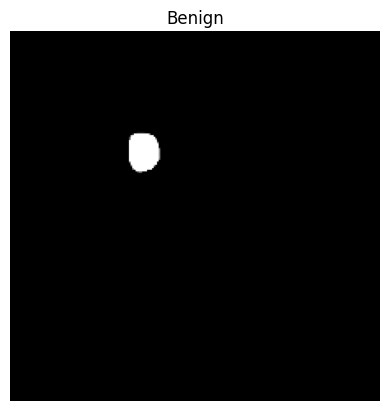

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction: Benign
True: Benign


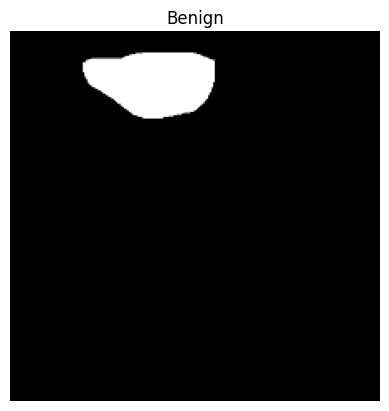

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Prediction: Benign
True: Benign


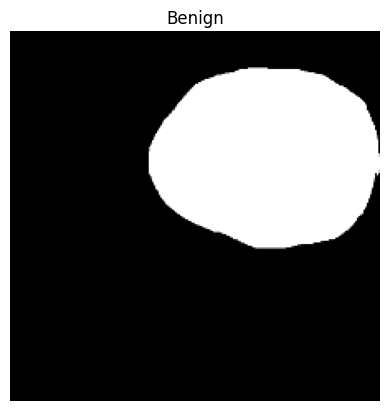

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Prediction: Benign
True: Benign


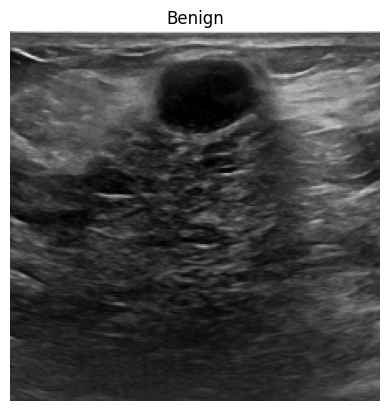

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Prediction: Benign
True: Benign


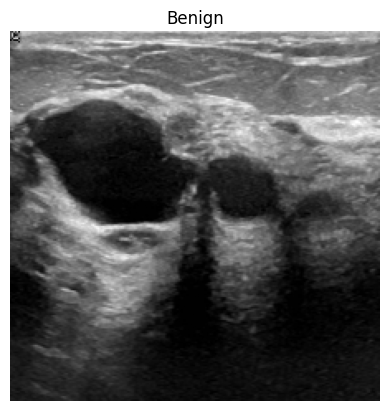

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Prediction: Benign
True: Benign


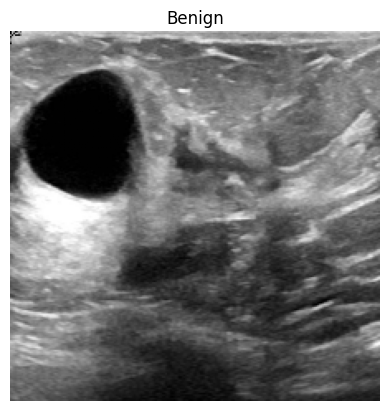

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Prediction: Benign
True: Benign


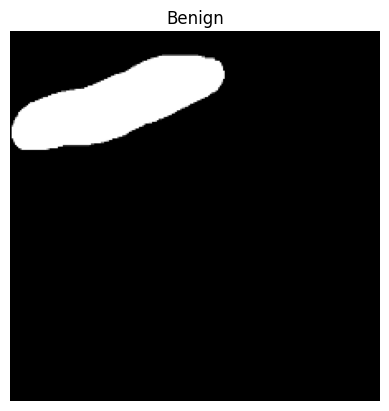

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Prediction: Benign
True: Malignant


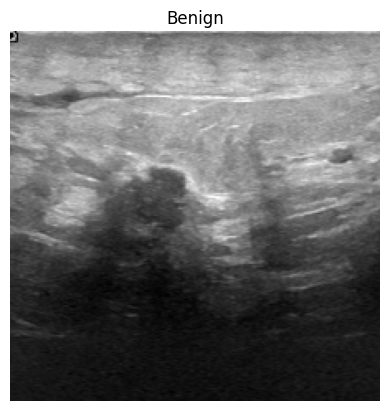

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction: Malignant
True: Malignant


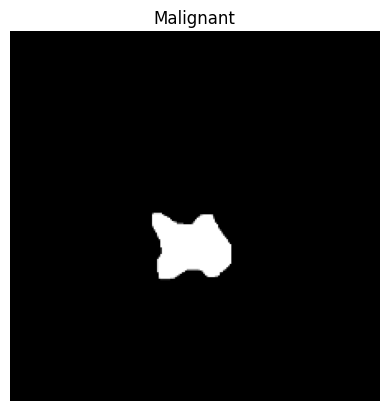

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Prediction: Benign
True: Benign


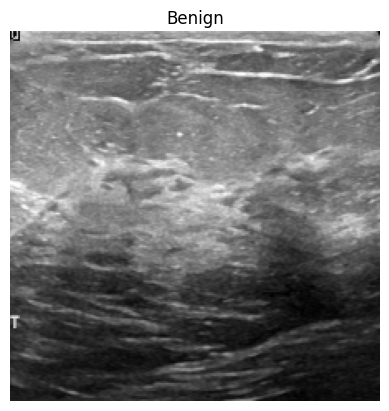

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Prediction: Malignant
True: Malignant


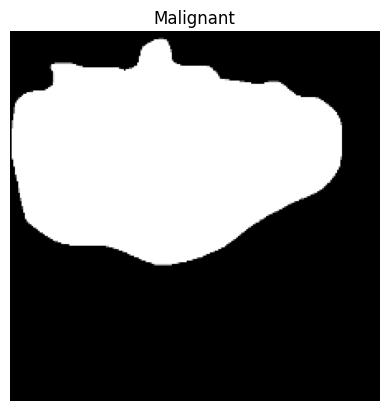

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Prediction: Malignant
True: Benign


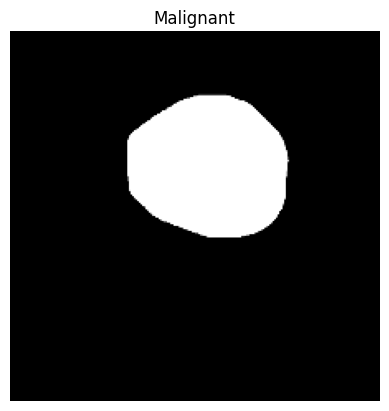

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction: Benign
True: Benign


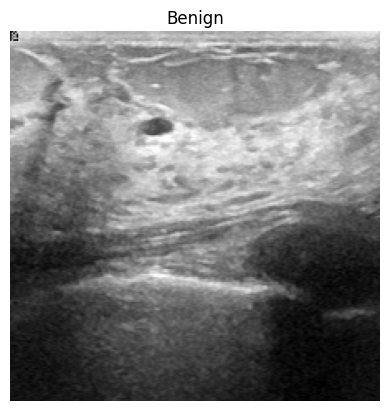

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Prediction: Benign
True: Benign


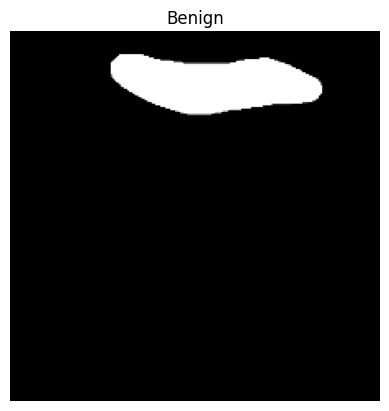

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Prediction: Benign
True: Benign


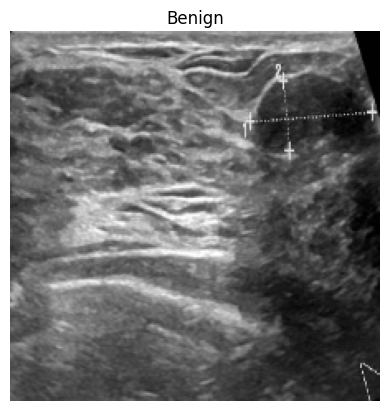

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Prediction: Benign
True: Malignant


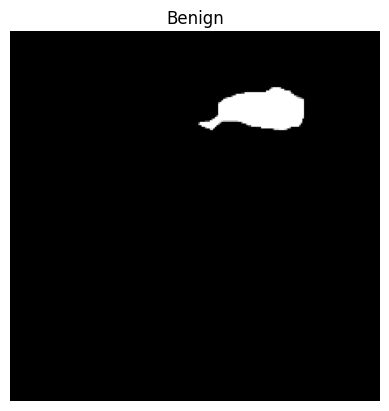

In [ ]:
for i in range(50):
    sample = X_test[i].reshape(1, 224, 224, 3)

    pred = model_type.predict(sample)[0][0]

    # Prediction
    label = "Malignant" if pred > 0.5 else "Benign"

    # Ground Truth
    true_label = "Malignant" if y_test[i] == 1 else "Benign"

    print("Prediction:", label)
    print("True:", true_label)

    plt.imshow(X_test[i])
    plt.title(label)
    plt.axis("off")
    plt.show()

In [ ]:
pred = model_type.predict(X_test)

pred = (pred > 0.5).astype(int)

print(pred[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 524ms/step
[[0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [ ]:
model_type.save("/content/drive/MyDrive/cnn_benign_malignant.h5")

NameError: name 'model_type' is not defined

In [ ]:
from google.colab import files

files.download("cnn_benign_malignant.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>